## Run Pysammos Coarse-Graining of Benchmark Model

### 1) Get the code ready for benchmarking!

Important note (go to README file for all the details): 

- the read point data source code has to be changed to read JP's contact data: in the module `pysammos.data_read.mfix.point_data`, go to the function `contacts` and comment out the code and uncomment the code below the comment "only to benchmark with JP's contact data reader"
    
- the sensitivity has to be increased to at least 10000 to have a smooth match across all w/d 

- change the c/w relation in `pysammos.spatial_weights_resolution.calc_cutoff` to c=w for Lucy 

### 2) Import packages

Note for developers: if you make any changes to the code and want to rerun the benchmarking test you must "Restart" and "Run All" again. 

In [1]:
from pysammos.utils.config_loader import load_config
from pysammos.coarse_graining import CoarseGraining 

Hello from pysammos
Loading macroscopic_fields package...
Loading data_read package...
Loading particle_phase package...
Loading spatial_weights package...
Loading neighbour_search package...
Loading grid_generation package...
Loading data_handle package...
Loading data_write package...


In [2]:
import numpy as np 

### 3) Run benchmark model on pysammos

1. Choose/define a smoothing function from: 'Lucy', 'Gaussian' and 'HeavySide'

In [3]:
cg_func = 'HeavySide'  

2. Define the Coarse-graining baseline widths and the widths for each function

In [4]:
# cg values used by JP: 
cgWidths = np.array([
    0.41666667, 0.5, 0.58333333, 0.66666667, 0.75,
    0.83333333, 0.91666667, 1.0, 1.08333333, 1.16666667,
    1.25, 1.33333333, 1.5, 1.75, 2.0,
    2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0
])

dp = 0.02  # particle diameter in m

Lucy_widths = cgWidths * dp * 3
Gaussian_widths = cgWidths * dp 
HeavySide_widths = cgWidths * dp *3

2. Initialise CoarseGraining class

In [5]:
# Load the configuration from the ini file
cfg = load_config("config.ini")  
print("-------------------- config.ini file read --------------------")
# Initialize the CoarseGraining class with the loaded configuration
CG = CoarseGraining(
    particle_path=cfg["particles_path"],
    contacts_path=cfg["contacts_path"],
    output_path=cfg["output_path"],
    start_timestep=cfg["t0"],
    end_timestep=cfg["tf"],
    dt_time_step=1, 
    DEM_keymap=cfg["key_mapping"],
    grid_info=cfg["grid_info"],
    weight_function= cg_func, #cfg["smoothing_function"]
    fields_to_export=cfg["fields_to_export"],
    ignore_phases=cfg["partialignore"],
    h5_output=cfg["h5_output"],
    vkthdf_output=cfg["vkthdf_output"],
    search_sampling_factor=10000
                    ) 
print("  ") ; print("-------------------- CoarseGraining class initialised --------------------")

-------------------- config.ini file read --------------------
Output path created: ./PysammosCG/
  
-------------------- CoarseGraining class initialised --------------------


3. Run the Coarse-graining for a sweep of CG widths

In [6]:
# Perform the sweep of CG widths
CG.sweep_CG_widths(w_d=eval(f"{cg_func}_widths")/0.02, center=np.array([0.0, 0.0, 0.42725]))
print(">> Sweep of CG widths completed.")

Starting coarse-graining resolution sweep...
XML-based PolyData detected.
 >>> Particle size used: d43 = 0.020000092103615797
CG range: c =  0.015000069077711849
 >>> Grid generated with 27 points.
 >>> Benchmark point index in grid: 13 at position [0.      0.      0.42725]
Loading data ... 
  Particle data loaded
Contact Data loaded as Cell Data
  Repeated pairs in contact data:  0
  Contact data loaded and mapped
  Coordination number not required. Skipping its calculation.
       -> Processing c/d = 1.2500)
Matching particles to grid points ...
... particles assigned to grid nodes
Computing weights ...
  Using HeavySide kernel with cutoff 0.025000115329520668 and search sampling factor 10000
... weights computed
Computing Coarse Graining fields...
  volume fraction done
  mixture density done
  momentum density done
  velocity done
  velocity gradient done
  kinetic tensor done
  contact tensor done
  total stress done
... fields computed
  File successfully updated to ./PysammosCG/

4. Check that you have indeed created a 3x3x3 CG grid centered in the point 0.0, 0.0, 0.42725

NOTE: the index of this point is printed in the cell above: (e.g., >>> Benchmark point index in grid: 13 at position [0.      0.      0.42725])

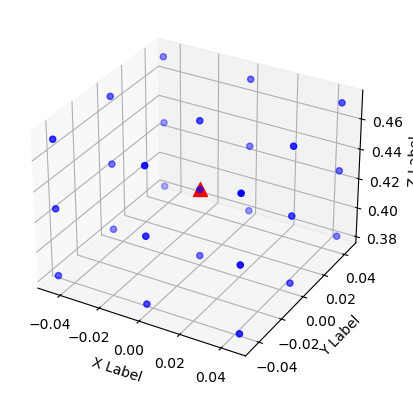

In [7]:
# plot CG.GridPoints in 3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(CG.GridPoints[:, 0], CG.GridPoints[:, 1], CG.GridPoints[:, 2], c='b', marker='o')
# plot center point in red
ax.scatter(0.0, 0.0, 0.42725, c='r', marker='^', s=100)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()